In [4]:
import pytesseract
import cv2
import numpy as np
import PIL
from pdf2image import convert_from_path
import os
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

In [5]:
out_put_images = "Sample Output Images"
os.makedirs(out_put_images, exist_ok=True)

In [6]:
images = convert_from_path(
  "sample.pdf",
  dpi=1000,
  poppler_path=r"D:\Programming\Projects\Learning python librairies\OCR\Release-26.02.0-0\poppler-26.02.0\Library\bin",
  thread_count=os.cpu_count()
)

In [7]:
import torch
import time

print("PyTorch version:", torch.__version__)
print("PyTorch CUDA version:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU count:", torch.cuda.device_count())

    # Create large tensors on the GPU
    device = torch.device("cuda")

    a = torch.randn(5000, 5000, device=device)
    b = torch.randn(5000, 5000, device=device)

    # Synchronize before timing
    torch.cuda.synchronize()

    start = time.time()

    c = torch.matmul(a, b)

    torch.cuda.synchronize()
    end = time.time()

    print("Matrix multiplication completed!")
    print("Time:", end - start, "seconds")
    print("Tensor device:", c.device)

else:
    print("CUDA is NOT available.")

PyTorch version: 2.6.0+cu124
PyTorch CUDA version: 12.4
CUDA available: True
GPU: NVIDIA GeForce GTX 1650
GPU count: 1
Matrix multiplication completed!
Time: 0.1974344253540039 seconds
Tensor device: cuda:0


In [8]:
sol = []
for i, image in enumerate(images):
  image_path = os.path.join(out_put_images, f"page_{i + 1}.png")
  image.save(image_path, "png")
  # Read the image using OpenCV
  img = cv2.imread(image_path)
  # Convert the image to grayscale
  gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  threshold_value,imgbin = cv2.threshold(gray, 0, 255, cv2.THRESH_OTSU+cv2.THRESH_BINARY)
  imgbin = cv2.bitwise_not(imgbin)
  
  cleaned = imgbin.copy()
  
  contours, _ = cv2.findContours(
    imgbin,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
  )
  
  image_area = imgbin.shape[0] * imgbin.shape[1]

  for contour in contours:
    # Get bounding rectangle
    x, y, w, h = cv2.boundingRect(contour)
    # Rectangle area
    area = w * h
    # Remove very large regions
    if area > 0.05 * image_area:
      cv2.rectangle(cleaned,(x, y),(x + w, y + h),0,-1)
  cleaned = np.array(cleaned)
  cleaned = cleaned[500:7900, :]
  sol.append(cleaned)
  text = pytesseract.image_to_string(cleaned, lang='eng')
  open("text.txt", 'a').write(text)
  cv2.imwrite(rf"Image_Trial\page {i}.png", cleaned)

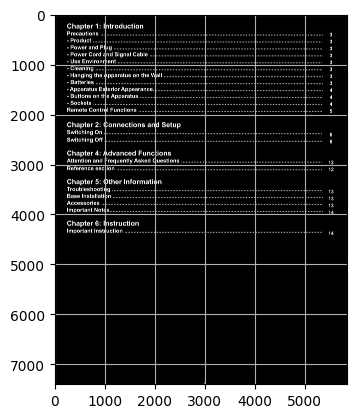

In [9]:
sol = np.array(sol)
plt.imshow(sol[1], cmap="gray")
plt.grid(True)
plt.show()

detect the table and extract the words from the cells

In [11]:
import cv2
import numpy as np
import os


# ==========================================
# 1. Read image
# ==========================================

image_path = r"D:\Programming\Projects\Learning python librairies\OCR\Data before preprocessing\page_10.png"

img = cv2.imread(image_path)


# ==========================================
# 2. Grayscale
# ==========================================

gray = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2GRAY
)


# ==========================================
# 3. Binary
#
# White = text / table lines
# Black = background
# ==========================================

_, binary = cv2.threshold(
    gray,
    0,
    255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)


# ==========================================
# 4. Detect horizontal lines
# ==========================================

horizontal_kernel_size = max(
    30,
    img.shape[1] // 30
)

horizontal_kernel = cv2.getStructuringElement(
    cv2.MORPH_RECT,
    (horizontal_kernel_size, 1)
)

horizontal_lines = cv2.morphologyEx(
    binary,
    cv2.MORPH_OPEN,
    horizontal_kernel
)


# ==========================================
# 5. Detect vertical lines
# ==========================================

vertical_kernel_size = max(
    30,
    img.shape[0] // 30
)

vertical_kernel = cv2.getStructuringElement(
    cv2.MORPH_RECT,
    (1, vertical_kernel_size)
)

vertical_lines = cv2.morphologyEx(
    binary,
    cv2.MORPH_OPEN,
    vertical_kernel
)


# ==========================================
# 6. Combine lines
# ==========================================

table_lines = cv2.bitwise_or(
    horizontal_lines,
    vertical_lines
)


# ==========================================
# 7. Connect lines belonging to the same table
# ==========================================

connect_kernel = cv2.getStructuringElement(
    cv2.MORPH_RECT,
    (20, 20)
)

table_mask = cv2.morphologyEx(
    table_lines,
    cv2.MORPH_CLOSE,
    connect_kernel
)


# ==========================================
# 8. Find table contours
# ==========================================

contours, _ = cv2.findContours(
    table_mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)


# ==========================================
# 9. Get candidate tables
# ==========================================

tables = []

image_area = (
    img.shape[0] *
    img.shape[1]
)


for contour in contours:

    x, y, w, h = cv2.boundingRect(
        contour
    )

    area = w * h


    # Ignore very small regions
    if (
        w >= 100
        and
        h >= 100
        and
        area >= 0.003 * image_area
    ):

        tables.append(
            (x, y, w, h)
        )


# ==========================================
# 10. Sort tables
#
# Top → bottom
# Left → right
# ==========================================

tables = sorted(
    tables,
    key=lambda box: (
        box[1],
        box[0]
    )
)


print(
    f"Detected {len(tables)} tables"
)


# ==========================================
# 11. Create output folder
# ==========================================

os.makedirs(
    "Detected_Tables",
    exist_ok=True
)


# ==========================================
# 12. Crop every table
# ==========================================

for table_number, (
    x,
    y,
    w,
    h
) in enumerate(
    tables,
    start=1
):

    # Padding around table
    padding = 15


    x1 = max(
        x - padding,
        0
    )

    y1 = max(
        y - padding,
        0
    )

    x2 = min(
        x + w + padding,
        img.shape[1]
    )

    y2 = min(
        y + h + padding,
        img.shape[0]
    )


    # ======================================
    # IMPORTANT:
    # Crop ORIGINAL image
    # ======================================

    table_crop = img[
        y1:y2,
        x1:x2
    ]


    output_path = os.path.join(
        "Detected_Tables",
        f"table_{table_number}.png"
    )


    cv2.imwrite(
        output_path,
        table_crop
    )


    print(
        f"Table {table_number} saved: "
        f"{output_path}"
    )


# ==========================================
# 13. Create debug image
# ==========================================

debug_image = img.copy()


for table_number, (
    x,
    y,
    w,
    h
) in enumerate(
    tables,
    start=1
):

    cv2.rectangle(
        debug_image,
        (x, y),
        (x + w, y + h),
        (0, 0, 255),
        5
    )


    cv2.putText(
        debug_image,
        f"TABLE {table_number}",
        (x, max(y - 15, 30)),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0, 0, 255),
        3
    )


cv2.imwrite(
    "Detected_Tables/debug_tables.png",
    debug_image
)

Detected 1 tables
Table 1 saved: Detected_Tables\table_1.png


True

Keep rubbish data

In [12]:
import os
import cv2
import numpy as np
import pandas as pd
import pytesseract


sol = []

for i, image in enumerate(images):

    # ==========================================
    # 1. Save page
    # ==========================================

    image_path = os.path.join(
        out_put_images,
        f"page_{i + 1}.png"
    )

    image.save(image_path, "png")


    # ==========================================
    # 2. Read image
    # ==========================================

    img = cv2.imread(image_path)


    # ==========================================
    # 3. Grayscale
    # ==========================================

    gray = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )


    # ==========================================
    # 4. Binary
    #
    # White = text / lines
    # Black = background
    # ==========================================

    _, imgbin = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    imgbin = cv2.bitwise_not(imgbin)


    # ==========================================================
    #                  TABLE DETECTION
    # ==========================================================

    # Keep the original binary image for table detection
    table_binary = imgbin.copy()


    # ==========================================
    # 5. Detect horizontal table lines
    # ==========================================

    horizontal_kernel_size = max(
        30,
        img.shape[1] // 30
    )

    horizontal_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (horizontal_kernel_size, 1)
    )

    horizontal_lines = cv2.morphologyEx(
        table_binary,
        cv2.MORPH_OPEN,
        horizontal_kernel
    )


    # ==========================================
    # 6. Detect vertical table lines
    # ==========================================

    vertical_kernel_size = max(
        30,
        img.shape[0] // 30
    )

    vertical_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (1, vertical_kernel_size)
    )

    vertical_lines = cv2.morphologyEx(
        table_binary,
        cv2.MORPH_OPEN,
        vertical_kernel
    )


    # ==========================================
    # 7. Combine table lines
    # ==========================================

    table_lines = cv2.bitwise_or(
        horizontal_lines,
        vertical_lines
    )


    # ==========================================
    # 8. Detect table regions
    # ==========================================

    table_contours, _ = cv2.findContours(
        table_lines,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )


    table_regions = []


    for contour in table_contours:

        x, y, w, h = cv2.boundingRect(contour)

        area = w * h

        # Ignore very small regions
        if (
            w > 100
            and
            h > 100
            and
            area > 0.005 * (
                img.shape[0] * img.shape[1]
            )
        ):

            table_regions.append(
                (x, y, w, h)
            )


    # ==========================================
    # 9. Sort tables from top to bottom
    # ==========================================

    table_regions = sorted(
        table_regions,
        key=lambda r: (r[1], r[0])
    )


    print(
        f"\nPage {i + 1}: "
        f"{len(table_regions)} table(s) detected."
    )


    # ==========================================================
    #             EXTRACT EACH TABLE
    # ==========================================================

    for table_number, (tx, ty, tw, th) in enumerate(
        table_regions,
        start=1
    ):

        # ======================================
        # Crop table
        # ======================================

        table_img = table_binary[
            ty:ty + th,
            tx:tx + tw
        ]


        # ======================================
        # Detect horizontal lines INSIDE table
        # ======================================

        table_horizontal_kernel = cv2.getStructuringElement(
            cv2.MORPH_RECT,
            (
                max(20, tw // 20),
                1
            )
        )

        table_horizontal_lines = cv2.morphologyEx(
            table_img,
            cv2.MORPH_OPEN,
            table_horizontal_kernel
        )


        # ======================================
        # Detect vertical lines INSIDE table
        # ======================================

        table_vertical_kernel = cv2.getStructuringElement(
            cv2.MORPH_RECT,
            (
                1,
                max(20, th // 20)
            )
        )

        table_vertical_lines = cv2.morphologyEx(
            table_img,
            cv2.MORPH_OPEN,
            table_vertical_kernel
        )


        # ======================================
        # Find horizontal positions
        # ======================================

        horizontal_projection = np.sum(
            table_horizontal_lines > 0,
            axis=1
        )

        horizontal_positions = np.where(
            horizontal_projection > 0
        )[0]


        # ======================================
        # Find vertical positions
        # ======================================

        vertical_projection = np.sum(
            table_vertical_lines > 0,
            axis=0
        )

        vertical_positions = np.where(
            vertical_projection > 0
        )[0]


        # ======================================
        # Group nearby positions
        # ======================================

        def group_positions(
            positions,
            distance=5
        ):

            if len(positions) == 0:
                return []

            groups = []

            start = positions[0]
            previous = positions[0]

            for position in positions[1:]:

                if (
                    position - previous
                    > distance
                ):

                    groups.append(
                        (start + previous) // 2
                    )

                    start = position

                previous = position

            groups.append(
                (start + previous) // 2
            )

            return groups


        horizontal_positions = group_positions(
            horizontal_positions
        )

        vertical_positions = group_positions(
            vertical_positions
        )


        # ======================================
        # Need at least one row and one column
        # ======================================

        if (
            len(horizontal_positions) < 2
            or
            len(vertical_positions) < 2
        ):

            print(
                f"Table {table_number}: "
                "Could not determine cells."
            )

            continue


        # ======================================
        # Extract cells
        # ======================================

        table_data = []


        for row in range(
            len(horizontal_positions) - 1
        ):

            row_data = []


            y1 = horizontal_positions[row]
            y2 = horizontal_positions[row + 1]


            for col in range(
                len(vertical_positions) - 1
            ):

                x1 = vertical_positions[col]
                x2 = vertical_positions[col + 1]


                # ------------------------------
                # Remove border from OCR crop
                # ------------------------------

                margin = 5

                x1_cell = max(
                    x1 + margin,
                    0
                )

                x2_cell = min(
                    x2 - margin,
                    table_img.shape[1]
                )

                y1_cell = max(
                    y1 + margin,
                    0
                )

                y2_cell = min(
                    y2 - margin,
                    table_img.shape[0]
                )


                if (
                    x2_cell <= x1_cell
                    or
                    y2_cell <= y1_cell
                ):

                    row_data.append("")

                    continue


                # ==================================
                # Crop cell
                # ==================================

                cell = gray[
                    ty + y1_cell:
                    ty + y2_cell,

                    tx + x1_cell:
                    tx + x2_cell
                ]


                # ==================================
                # OCR cell
                # ==================================

                text = pytesseract.image_to_string(
                    cell,
                    lang="eng+ara",
                    config="--psm 6"
                )


                # Clean OCR output
                text = " ".join(
                    text.split()
                )


                row_data.append(
                    text
                )


            table_data.append(
                row_data
            )


        # ======================================================
        #                 SAVE TABLE
        # ======================================================

        df = pd.DataFrame(
            table_data
        )


        # Remove completely empty rows
        df = df.dropna(
            how="all"
        )


        # Remove completely empty columns
        df = df.dropna(
            axis=1,
            how="all"
        )


        # ======================================
        # Save CSV
        # ======================================

        csv_path = os.path.join(
            "Tables",
            f"page_{i + 1}_table_{table_number}.csv"
        )

        os.makedirs(
            "Tables",
            exist_ok=True
        )


        df.to_csv(
            csv_path,
            index=False,
            header=False,
            encoding="utf-8-sig"
        )


        print(
            f"Saved: {csv_path}"
        )


    # ==========================================================
    #                  NORMAL OCR PREPROCESSING
    # ==========================================================

    # ==========================================
    # Create border mask
    # ==========================================

    table_lines = cv2.bitwise_or(
        horizontal_lines,
        vertical_lines
    )


    # ==========================================
    # Remove ONLY table borders
    #
    # Original text is preserved.
    # ==========================================

    cleaned = imgbin.copy()

    cleaned[
        table_lines > 0
    ] = 0


    # ==========================================
    # Find connected components
    # ==========================================

    num_labels, labels, stats, centroids = \
        cv2.connectedComponentsWithStats(
            cleaned,
            connectivity=8
        )


    image_height, image_width = cleaned.shape

    image_area = (
        image_height *
        image_width
    )


    # ==========================================
    # Remove obvious large image regions
    # ==========================================

    for label in range(
        1,
        num_labels
    ):

        x = stats[
            label,
            cv2.CC_STAT_LEFT
        ]

        y = stats[
            label,
            cv2.CC_STAT_TOP
        ]

        w = stats[
            label,
            cv2.CC_STAT_WIDTH
        ]

        h = stats[
            label,
            cv2.CC_STAT_HEIGHT
        ]

        component_area = stats[
            label,
            cv2.CC_STAT_AREA
        ]

        bbox_area = w * h

        density = (
            component_area /
            bbox_area
        )

        page_ratio = (
            component_area /
            image_area
        )


        if (
            page_ratio > 0.01
            and
            bbox_area > 0.04 * image_area
            and
            w > 100
            and
            h > 100
            and
            density > 0.15
        ):

            cleaned[
                labels == label
            ] = 0


    # ==========================================
    # Crop
    # ==========================================

    cleaned = cleaned[
        500:7900,
        :
    ]


    # ==========================================
    # Save processed image
    # ==========================================

    sol.append(
        cleaned
    )


    cv2.imwrite(
        rf"Image_Trial\page_{i + 1}.png",
        cleaned
    )


    # ==========================================
    # Normal OCR
    # ==========================================

    text = pytesseract.image_to_string(
        cleaned,
        lang="eng+ara"
    )


    # ==========================================
    # Save OCR text
    # ==========================================

    with open(
        "text.txt",
        "a",
        encoding="utf-8"
    ) as f:

        f.write(
            f"\n\n========== PAGE {i + 1} ==========\n\n"
        )

        f.write(text)


Page 1: 3 table(s) detected.
Table 1: Could not determine cells.
Table 2: Could not determine cells.
Table 3: Could not determine cells.

Page 2: 1 table(s) detected.
Table 1: Could not determine cells.

Page 3: 2 table(s) detected.
Table 1: Could not determine cells.
Table 2: Could not determine cells.

Page 4: 1 table(s) detected.
Table 1: Could not determine cells.

Page 5: 2 table(s) detected.
Table 1: Could not determine cells.
Table 2: Could not determine cells.

Page 6: 8 table(s) detected.
Table 1: Could not determine cells.
Table 2: Could not determine cells.
Table 3: Could not determine cells.
Table 4: Could not determine cells.
Table 5: Could not determine cells.
Table 6: Could not determine cells.
Table 7: Could not determine cells.
Table 8: Could not determine cells.

Page 7: 8 table(s) detected.
Table 1: Could not determine cells.
Table 2: Could not determine cells.
Table 3: Could not determine cells.
Table 4: Could not determine cells.
Table 5: Could not determine cells

bad data text

In [13]:
sol = []

for i, image in enumerate(images):

    # ==========================================
    # 1. Save page
    # ==========================================

    image_path = os.path.join(
        out_put_images,
        f"page_{i + 1}.png"
    )

    image.save(image_path, "png")


    # ==========================================
    # 2. Read image
    # ==========================================

    img = cv2.imread(image_path)


    # ==========================================
    # 3. Grayscale
    # ==========================================

    gray = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )


    # ==========================================
    # 4. Binary
    #    White = text / lines
    #    Black = background
    # ==========================================

    _, imgbin = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    imgbin = cv2.bitwise_not(imgbin)


    # ==========================================
    # 5. Detect horizontal table borders
    # ==========================================

    horizontal_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (50, 1)
    )

    horizontal_lines = cv2.morphologyEx(
        imgbin,
        cv2.MORPH_OPEN,
        horizontal_kernel
    )


    # ==========================================
    # 6. Detect vertical table borders
    # ==========================================

    vertical_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (1, 50)
    )

    vertical_lines = cv2.morphologyEx(
        imgbin,
        cv2.MORPH_OPEN,
        vertical_kernel
    )


    # ==========================================
    # 7. Combine table borders
    # ==========================================

    table_lines = cv2.bitwise_or(
        horizontal_lines,
        vertical_lines
    )


    # ==========================================
    # 8. Remove ONLY table borders
    #
    # Text inside the table is NOT removed.
    # ==========================================

    cleaned = cv2.subtract(
        imgbin,
        table_lines
    )


    # ==========================================
    # 9. Find connected components AFTER
    #    removing table borders
    # ==========================================

    num_labels, labels, stats, centroids = \
        cv2.connectedComponentsWithStats(
            cleaned,
            connectivity=8
        )


    image_height, image_width = cleaned.shape

    image_area = image_height * image_width


    # ==========================================
    # 10. Remove large image regions
    # ==========================================

    for label in range(1, num_labels):

        x = stats[label, cv2.CC_STAT_LEFT]
        y = stats[label, cv2.CC_STAT_TOP]

        w = stats[label, cv2.CC_STAT_WIDTH]
        h = stats[label, cv2.CC_STAT_HEIGHT]

        component_area = stats[label, cv2.CC_STAT_AREA]

        bbox_area = w * h

        density = component_area / bbox_area

        page_ratio = component_area / image_area


        # Large component
        large_component = (
            component_area > 0.01 * image_area
        )


        # Large bounding box
        large_bbox = (
            bbox_area > 0.04 * image_area
        )


        # ======================================
        # Remove large image-like components
        # ======================================

        if large_component or large_bbox:

            # Don't remove very thin components
            # because they may be text or remaining lines

            if w > 20 and h > 20:

                if density > 0.15:

                    cleaned[labels == label] = 0


    # ==========================================
    # 11. Crop
    # ==========================================

    cleaned = cleaned[500:7900, :]


    # ==========================================
    # 12. Save processed image
    # ==========================================

    sol.append(cleaned)

    cv2.imwrite(
        rf"Image_Trial\page_{i + 1}.png",
        cleaned
    )


    # ==========================================
    # 13. OCR
    # ==========================================

    text = pytesseract.image_to_string(
        cleaned,
        lang="eng+ara"
    )


    # ==========================================
    # 14. Save OCR
    # ==========================================

    with open(
        "text.txt",
        "a",
        encoding="utf-8"
    ) as f:

        f.write(
            f"\n\n========== PAGE {i + 1} ==========\n\n"
        )

        f.write(text)

In [ ]:
sol = []

for i, image in enumerate(images):

    # ==========================================
    # 1. Save page
    # ==========================================

    image_path = os.path.join(
        out_put_images,
        f"page_{i + 1}.png"
    )

    image.save(image_path, "png")


    # ==========================================
    # 2. Read image
    # ==========================================

    img = cv2.imread(image_path)


    # ==========================================
    # 3. Grayscale
    # ==========================================

    gray = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )


    # ==========================================
    # 4. Binary
    #
    # White = text / lines
    # Black = background
    # ==========================================

    _, imgbin = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    imgbin = cv2.bitwise_not(imgbin)


    # ==========================================
    # 5. Create a COPY for border detection
    #
    # IMPORTANT:
    # We will NEVER use this modified image
    # as the final OCR image.
    # ==========================================

    border_detection = imgbin.copy()


    # ==========================================
    # 6. Detect horizontal table borders
    # ==========================================

    horizontal_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (50, 1)
    )

    horizontal_lines = cv2.morphologyEx(
        border_detection,
        cv2.MORPH_OPEN,
        horizontal_kernel
    )


    # ==========================================
    # 7. Detect vertical table borders
    # ==========================================

    vertical_kernel = cv2.getStructuringElement(
        cv2.MORPH_RECT,
        (1, 50)
    )

    vertical_lines = cv2.morphologyEx(
        border_detection,
        cv2.MORPH_OPEN,
        vertical_kernel
    )


    # ==========================================
    # 8. Combine table-border masks
    # ==========================================

    table_lines = cv2.bitwise_or(
        horizontal_lines,
        vertical_lines
    )


    # ==========================================
    # 9. Remove ONLY detected border pixels
    #
    # The original text pixels are NOT
    # morphologically modified.
    # ==========================================

    cleaned = imgbin.copy()

    cleaned[table_lines > 0] = 0


    # ==========================================
    # 10. Find connected components
    # ==========================================

    num_labels, labels, stats, centroids = \
        cv2.connectedComponentsWithStats(
            cleaned,
            connectivity=8
        )


    image_height, image_width = cleaned.shape

    image_area = image_height * image_width


    # ==========================================
    # 11. Detect large image regions
    # ==========================================

    for label in range(1, num_labels):

        x = stats[label, cv2.CC_STAT_LEFT]
        y = stats[label, cv2.CC_STAT_TOP]

        w = stats[label, cv2.CC_STAT_WIDTH]
        h = stats[label, cv2.CC_STAT_HEIGHT]

        component_area = stats[
            label,
            cv2.CC_STAT_AREA
        ]

        bbox_area = w * h

        density = component_area / bbox_area

        page_ratio = component_area / image_area


        # ======================================
        # Large component
        # ======================================

        large_component = (
            page_ratio > 0.01
        )


        # ======================================
        # Large bounding box
        # ======================================

        large_bbox = (
            bbox_area > 0.04 * image_area
        )


        # ======================================
        # Very large region
        #
        # We require BOTH dimensions to be
        # reasonably large.
        # ======================================

        large_dimensions = (
            w > 100 and
            h > 100
        )


        # ======================================
        # Remove only obvious large regions
        # ======================================

        if (
            large_component
            and
            large_bbox
            and
            large_dimensions
            and
            density > 0.15
        ):

            cleaned[labels == label] = 0


    # ==========================================
    # 12. Crop
    # ==========================================

    cleaned = cleaned[500:7900, :]


    # ==========================================
    # 13. Save processed image
    # ==========================================

    sol.append(cleaned)

    cv2.imwrite(
        rf"Image_Trial\page_{i + 1}.png",
        cleaned
    )


    # ==========================================
    # 14. OCR
    # ==========================================

    text = pytesseract.image_to_string(
        cleaned,
        lang="eng+ara"
    )


    # ==========================================
    # 15. Save OCR
    # ==========================================

    with open(
        "text.txt",
        "a",
        encoding="utf-8"
    ) as f:

        f.write(
            f"\n\n========== PAGE {i + 1} ==========\n\n"
        )

        f.write(text)